<a href="https://colab.research.google.com/github/JoseRebollar95/MobilidadUrbana/blob/main/S5_ladb_mobility_economy_project_student_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [ ]:
traffic.info()
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo object, es decir, python las interpreta como texto por lo cual no las podrá extraer fechas si no se convierten a datetime64, no se podran usar formulas que las divida por año o mes.
- No se observa que en count presente algun tipo de valores nulos, esto nos lleva a dos probabilidades, que el dataset este completo o en caso de que exista algún nulo python lo interpreta como valor, ya sea que, este escrito 'Nan' o 'Sin Información'

In [ ]:
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, son object, es decir que python lo interpreta como texto y no como numericas
- No se observa que count muestre un valor nulo.

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [ ]:
traffic=traffic.rename(columns={'Country':'country','UpdateTimeUTC':'update_time_utc','City':'city','JamsDelay':'jams_delay','TrafficIndexLive':'traffic_index_live','JamsLengthInKms':'jams_lenght_in_kms','JamsCount':'jams_count', 'TrafficIndexWeekAgo':'traffic_index_week_ago',
       'UpdateTimeUTCWeekAgo':'update_time_utc_week_ago', 'TravelTimeLivePer10KmsMins':'travel_time_live_per_10_kms_mins',
       'TravelTimeHistoricPer10KmsMins':'travel_time_historic_per_10_kms_mins', 'MinsDelay':'mins_delay'})
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_lenght_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10_kms_mins',
       'travel_time_historic_per_10_kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
eco=eco.rename(columns={'Year':'year', 'City':'city', 'Country':'country', 'city_gdp_per_capita':'city_gpd_per_capita', 'Unemployment %':'unemployment_percentage',
       'PM2.5 (μg/m³)':'pm2.5', 'population':'population_m'})
eco.columns

Index(['year', 'city', 'country', 'city_gpd_per_capita',
       'unemployment_percentage', 'pm2.5', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [ ]:
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors="coerce", utc=True)
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors="coerce", utc=True)
# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                                Non-Null Count    Dtype              
---  ------                                --------------    -----              
 0   country                               1004464 non-null  object             
 1   city                                  1004464 non-null  object             
 2   update_time_utc                       1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                            1004464 non-null  float64            
 4   traffic_index_live                    1004464 non-null  float64            
 5   jams_lenght_in_kms                    1004464 non-null  float64            
 6   jams_count                            1004464 non-null  float64            
 7   traffic_index_week_ago                1004464 non-null  float64            
 8   update_time_utc_week_ago              1004464 non-null  datetime64[ns, U

In [ ]:

# 1. Crear una copia para trabajar seguros
eco_final = eco.copy()

# 2. Limpieza de GDP (city_gpd_per_capita)
eco_final["city_gpd_per_capita"] = eco_final["city_gpd_per_capita"].astype(str).str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
eco_final["city_gpd_per_capita"] = pd.to_numeric(eco_final["city_gpd_per_capita"], errors="coerce")

# 3. Limpieza de Desempleo (unemployment_percentage)
eco_final["unemployment_percentage"] = eco_final["unemployment_percentage"].astype(str).str.replace("%", "", regex=False).str.replace(",", ".", regex=False)
eco_final["unemployment_percentage"] = pd.to_numeric(eco_final["unemployment_percentage"], errors="coerce")

# 4. Limpieza de PM2.5 y Población (population_m)
eco_final["pm2.5"] = pd.to_numeric(eco_final["pm2.5"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
eco_final["population_m"] = pd.to_numeric(eco_final["population_m"].astype(str).str.replace(",", ".", regex=False), errors="coerce")

# 5. Crear columna population
eco_final["population"] = eco_final["population_m"] * 1000000

# Actualizar el original y verificar
eco = eco_final
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     30 non-null     int64  
 1   city                     30 non-null     object 
 2   country                  30 non-null     object 
 3   city_gpd_per_capita      30 non-null     int64  
 4   unemployment_percentage  30 non-null     float64
 5   pm2.5                    30 non-null     float64
 6   population_m             30 non-null     float64
 7   population               30 non-null     float64
dtypes: float64(4), int64(2), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gpd_per_capita,unemployment_percentage,pm2.5,population_m,population
0,2023,buenos-aires,Argentina,157820,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,144750,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,131420,9.8,19.1,13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [ ]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_lenght_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [ ]:

# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()
# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())



,country,city,update_time_utc,jams_delay,traffic_index_live,jams_lenght_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gpd_per_capita,unemployment_percentage,pm2.5,population_m,population
15,2024,buenos-aires,Argentina,181170,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,147030,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,133490,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,162510,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,88990,12.4,15.2,3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [ ]:
# Calcular los promedios de tráfico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(['city', 'country', 'year'])[[
    'jams_delay',
    'traffic_index_live',
    'jams_lenght_in_kms',
    'jams_count',
    'mins_delay',
    'travel_time_live_per_10_kms_mins',
    'travel_time_historic_per_10_kms_mins'
]].mean().reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_lenght_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_lenght_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es Ciudad de México


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [ ]:
# 1. Seleccionar columnas clave (ajustadas a tus nombres reales)
left_cols = ['city', 'country', 'year', 'jams_delay', 'traffic_index_live',
             'jams_lenght_in_kms', 'jams_count', 'mins_delay',
             'travel_time_live_per_10_kms_mins', 'travel_time_historic_per_10_kms_mins']

right_cols = ['city', 'year', 'city_gpd_per_capita', 'unemployment_percentage', 'pm2.5', 'population']

# 2. Usar .copy() para crear los subconjuntos reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# 3. Unir datasets (Inner Join para mantener solo lo presente en ambos)
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

# 4. Mostrar las primeras 5 filas
merged.head(5)

,city,country,year,jams_delay,traffic_index_live,jams_lenght_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,city_gpd_per_capita,unemployment_percentage,pm2.5,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,111240,9.5,16.8,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,114420,10.0,17.6,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,162510,7.8,12.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,181170,7.2,14.5,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,123810,8.2,13.5,3700000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

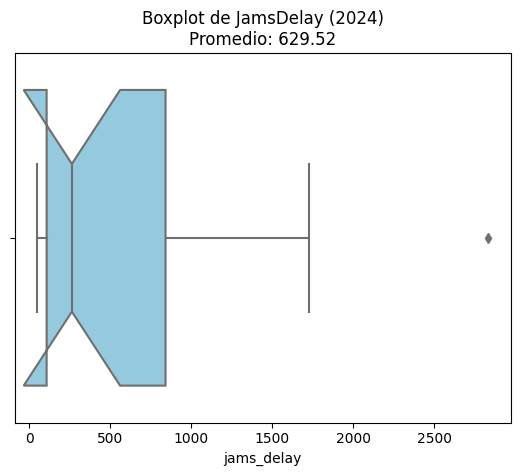

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
sns.boxplot(x=merged['jams_delay'], color='skyblue', notch=True)
# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


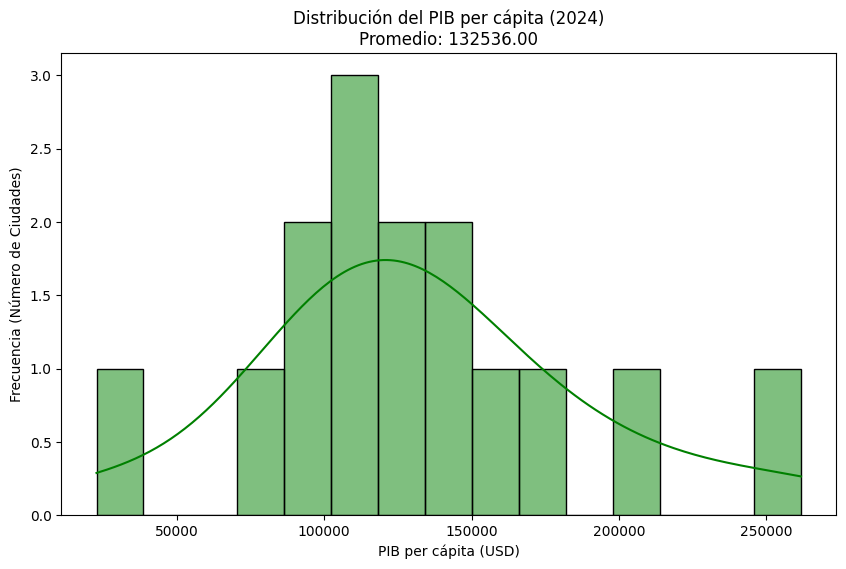

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
# 1. Configurar el tamaño
plt.figure(figsize=(10, 6))

# 2. Crear el histograma con una línea de densidad (kde)
sns.histplot(merged['city_gpd_per_capita'], kde=True, color='green', bins=15)

# 3. Calcular el promedio para el título
gdp_mean = merged['city_gpd_per_capita'].mean()

# 4. Etiquetas y título
plt.title(f'Distribución del PIB per cápita (2024)\nPromedio: {gdp_mean:.2f}')
plt.xlabel('PIB per cápita (USD)')
plt.ylabel('Frecuencia (Número de Ciudades)')

# Mostrar
plt.show()


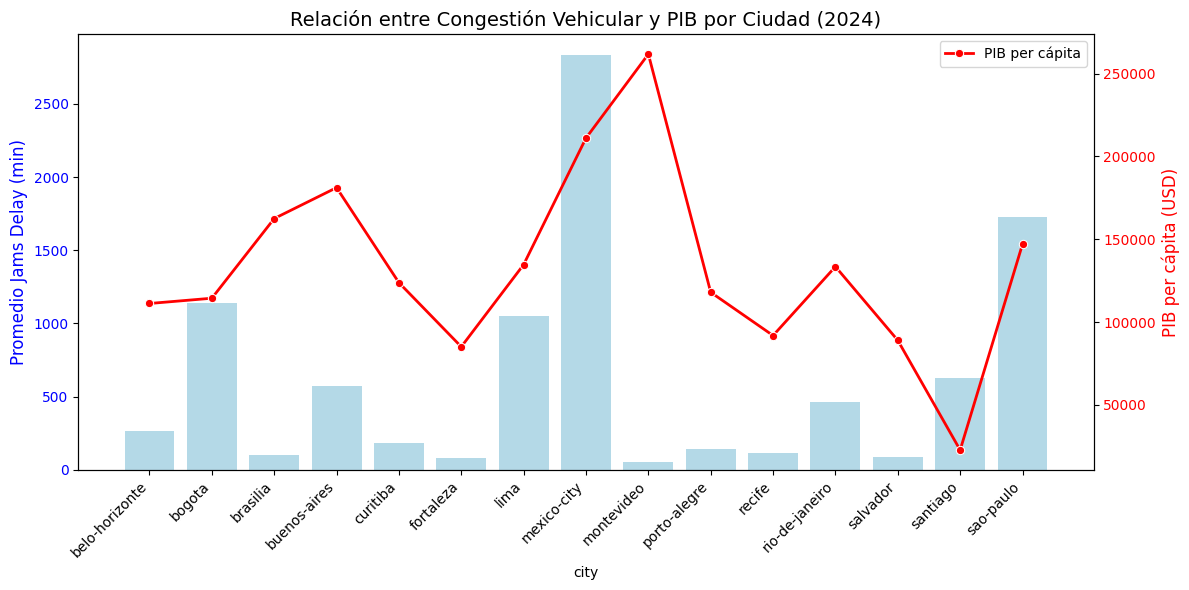

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
# Crear la figura y el primer eje (Tráfico)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Gráfico de barras para el Tráfico (Jams Delay)
sns.barplot(data=merged, x='city', y='jams_delay', ax=ax1, color='skyblue', alpha=0.7, label='Tráfico (Jams Delay)')
ax1.set_ylabel('Promedio Jams Delay (min)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=45, ha='right')

# Crear el segundo eje para el PIB (Economy)
ax2 = ax1.twinx()
sns.lineplot(data=merged, x='city', y='city_gpd_per_capita', ax=ax2, color='red', marker='o', linewidth=2, label='PIB per cápita')
ax2.set_ylabel('PIB per cápita (USD)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Título y ajustes
plt.title('Relación entre Congestión Vehicular y PIB por Ciudad (2024)', fontsize=14)
fig.tight_layout()

# Mostrar gráfico
plt.show()


**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios: No existe una relación clara. La ciudad de México es la megaciudad con mas tráfico y la en la grafica la segunda de mejor PIB, esto sugiere que el crecimiento económico ha superado la capacidad de la infraestructura. Sin embargo Montevideo es la ciudad con PIB per cápida más alto pero es la menor en promedio de tráfico. Por último el caso de Santiago, en grafica, parece ser la mediana en promedio de trafico, sin embargo es la mas baja del PIB per cápita. Lo cual sugiere que el problema no es el trafico, sin embargo, el tráfico si responde a diversos factores como: densidad poblacional, diseño urbano y transporte público.


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [ ]:
# Exportar el DataFrame final a un archivo CSV
merged.to_csv('ladb_mobility_economy_2024_clean.csv', index=False)

# Confirmación de exportación
print("¡Archivo exportado exitosamente como: ladb_mobility_economy_2024_clean.csv!")

¡Archivo exportado exitosamente como: ladb_mobility_economy_2024_clean.csv!


Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información.


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.

**Cobertura de datos:**  
- Especifica los años analizados, número de ciudades y países incluidos.

**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).
- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).

**Hallazgos iniciales:**  
- Resume los patrones más importantes entre índices de tráfico y PIB per cápita.
- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.

**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?


##Resumen Ejecutivo: Impacto de la Movilidad en la Economía Latinoamericana (2024)
---
#Contexto & Objetivo
Tras integrar los datasets de tráfico y economía, el análisis revela que no existe una correlación lineal directa entre la congestión urbana y el PIB per cápita en las ciudades latinoamericanas estudiadas.

Desmitificación: Se observa que un mayor poder adquisitivo no se traduce automáticamente en una movilidad más eficiente ni en una peor congestión.

Contraste Crítico: Ciudades como Montevideo demuestran que es posible alcanzar niveles altos de productividad manteniendo tiempos de viaje bajos. En el extremo opuesto, Ciudad de México muestra que una alta actividad económica puede convivir con un colapso vial severo (~2800 min de retraso), lo que sugiere que factores como la planificación urbana y la densidad poblacional tienen un peso mayor que el factor económico por sí solo.

#Cobertura de datos
Años analizados: El análisis se centró exclusivamente en el año 2024, tras filtrar y promediar los datos históricos para obtener una comparativa reciente y relevante.

Número de ciudades: El dataset final (merged) incluye un total de 14 ciudades latinoamericanas. Estas son las ciudades que contaban con información completa tanto en los registros de tráfico como en los indicadores económicos.

Países incluidos: Se cubren 6 países de la región, proporcionando una muestra representativa de diversas economías (Brasil, México, Colombia, Perú, Argentina y Uruguay).

#Metodología
Limpieza y Estandarización de Datos: * Se transformaron variables críticas (como el PIB per cápita y la tasa de desempleo) de formatos de texto a numéricos (float64) para permitir cálculos estadísticos.

Se estandarizaron los nombres de las columnas para asegurar consistencia entre ambos datasets (uso de snake_case y eliminación de caracteres especiales).

Agregación y Consolidación:

Se realizó una agregación por ciudad y año, calculando el promedio de los indicadores de tráfico diarios para obtener una métrica anual representativa del 2024.

Se integraron las fuentes mediante una unión de tipo INNER JOIN, utilizando city y year como claves de cruce. Esto garantizó que el análisis final solo incluyera ciudades con datos validados en ambas dimensiones (económica y de movilidad).

Validación Visual y Control de Calidad:

Distribución: Se utilizaron histogramas para analizar la concentración del PIB y entender la forma de la riqueza en la región.

Detección de Outliers: Mediante el uso de boxplots, se identificaron valores atípicos en la congestión (jams_delay), permitiendo aislar casos extremos como la Ciudad de México que podrían sesgar los promedios generales.

Análisis de Tendencias: Se implementaron gráficos de ejes duales para comparar visualmente variables con diferentes escalas (minutos vs. USD) y buscar correlaciones o anomalías.

#Hallazgos iniciales

Hallazgos Iniciales: Tráfico vs. PIB
Ausencia de Correlación Lineal: Los datos muestran que un mayor PIB per cápita no garantiza una mejor movilidad. Ciudades con niveles económicos similares presentan realidades de tráfico opuestas, lo que sugiere que la gestión urbana es más determinante que la riqueza nacional.

El "Techo" de la Productividad: En ciudades como Bogotá y Lima, los altos índices de congestión en relación con un PIB per cápita moderado actúan como un impuesto a la productividad, restando horas hombre que podrían destinarse a actividades económicas.

Eficiencia en el Cono Sur: Montevideo se posiciona como el referente de eficiencia en la muestra, logrando el PIB per cápita más alto con niveles de congestión mínimos, lo que indica una infraestructura equilibrada frente a su demanda.

Anomalías y Outliers Detectados
Outlier Crítico (Mexico City): La Ciudad de México presenta un jams_delay de aproximadamente 2,800 minutos, un valor que se aleja drásticamente del promedio regional (629.52 min). Esta anomalía requiere un análisis profundo para separar el impacto de la densidad poblacional del impacto de la infraestructura física.

Anomalía de Santiago: Santiago registra el PIB per cápita más bajo de la muestra analizada, sin embargo, su congestión es superior a la de ciudades con mayor solvencia económica como Brasilia o Curitiba. Este desbalance sugiere una vulnerabilidad en su sistema de transporte masivo.

Estabilidad en ciudades brasileñas: Ciudades como Belo Horizonte y Recife muestran una consistencia notable; a pesar de tener PIB moderados, mantienen niveles de tráfico controlados, lo que podría señalar políticas de movilidad exitosas a escala media.

#Recomendaciones

1. Identificación de Ciudades Prioritarias para Inversión
Tras analizar la relación entre congestión y productividad, la respuesta es clara: Bogotá y Lima son las ciudades prioritarias para inversión en infraestructura.

El hallazgo: Mientras que Buenos Aires muestra un equilibrio relativo entre su riqueza y su tráfico, Bogotá y Lima presentan niveles de congestión muy elevados (superando los 1,000 minutos de retraso) a pesar de tener indicadores de PIB per cápita que se encuentran en el rango medio-bajo de la muestra.

Justificación: En estas ciudades, la infraestructura de transporte actúa como un "freno" a la productividad. Invertir aquí generaría el mayor retorno social y económico, ya que reducir los tiempos de viaje liberaría horas productivas en economías que aún tienen mucho margen de crecimiento.

2. Validación y Profundización de Datos
Validación de Fuentes: Es imperativo cruzar los datos de jams_delay con el número total de vehículos registrados en cada ciudad para normalizar el índice de congestión.

Análisis de Transporte Público: Se recomienda integrar datos sobre la cobertura de metros y sistemas de transporte masivo. Esto permitiría confirmar si el éxito de ciudades como Montevideo se debe a su gestión de red vial o a una baja dependencia del automóvil particular.

3. Propuestas de Inversión y Acción
Estudio de Benchmarking: Realizar una misión técnica a Montevideo y Curitiba para documentar sus políticas de movilidad, dado que muestran indicadores de eficiencia superiores al resto de la región.

Foco en Megaciudades (Outliers): Para el caso de Ciudad de México, la recomendación no es solo infraestructura física, sino inversión en tecnologías de gestión de tráfico inteligente (Smart Traffic), dado que la escala del problema parece haber superado las soluciones de construcción tradicional.

Sostenibilidad: Dado que el PIB per cápita tiene una distribución dispersa, las inversiones deben estar ligadas a la reducción de la variable PM2.5, asegurando que el crecimiento económico sea verde y no solo motorizado.
